# Customer Retention & Engagement Analytics

This notebook focuses on data profiling, validation and cleaning for an e-commerce customer churn dataset.

The objective is to clean, validate and analyse customer-level data to identify behavioural patterns associated with customer churn and support retention decision-making.

In [147]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

## Data Loading

The raw dataset is loaded into a pandas DataFrame for initial inspection.

At this stage, no transformations are applied. The purpose is to preserve the original source data and establish a baseline for later reconciliation.

In [148]:
df = pd.read_csv("/content/drive/MyDrive/Churn_Analysis/ecommerce_customer_churn_dataset.csv")

## Initial Data Inspection

This section examines the structure of the dataset, including:

- Number of rows and columns
- Column names
- Data types
- Sample records
- Initial summary statistics

The objective is to understand the overall shape and structure of the raw data before making any cleaning decisions.

In [149]:
df.shape

(50000, 25)

In [150]:
df.head()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


In [151]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  object 
 2   Country                        50000 non-null  object 
 3   City                           50000 non-null  object 
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  float64
 6   Session_Duration_Avg           46601 non-null  float64
 7   Pages_Per_Session              47000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 46000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value            50000 non-null  float64
 12  Days_Since_Last_Purchase       47000 non-null 

In [152]:
df.columns

Index(['Age', 'Gender', 'Country', 'City', 'Membership_Years',
       'Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session',
       'Cart_Abandonment_Rate', 'Wishlist_Items', 'Total_Purchases',
       'Average_Order_Value', 'Days_Since_Last_Purchase',
       'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate',
       'Customer_Service_Calls', 'Product_Reviews_Written',
       'Social_Media_Engagement_Score', 'Mobile_App_Usage',
       'Payment_Method_Diversity', 'Lifetime_Value', 'Credit_Balance',
       'Churned', 'Signup_Quarter'],
      dtype='object')

In [153]:
df.describe(include= 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,47505.0,NaN,NaN,NaN,37.802968,11.834668,5.0,29.0,38.0,46.0,200.0
Gender,50000,3,Female,25116,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,50000,8,USA,17384,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,50000,40,Houston,3549,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Membership_Years,50000.0,NaN,NaN,NaN,2.984009,2.059105,0.1,1.4,2.5,4.0,10.0
Login_Frequency,50000.0,NaN,NaN,NaN,11.62466,7.810657,0.0,6.0,11.0,17.0,46.0
Session_Duration_Avg,46601.0,NaN,NaN,NaN,27.660754,10.871013,1.0,19.7,26.8,34.7,75.6
Pages_Per_Session,47000.0,NaN,NaN,NaN,8.737811,3.77822,1.0,6.0,8.4,11.2,24.1
Cart_Abandonment_Rate,50000.0,NaN,NaN,NaN,57.079973,16.282723,0.0,46.4,58.1,68.7,143.74335
Wishlist_Items,46000.0,NaN,NaN,NaN,4.298391,3.189754,0.0,2.0,4.0,6.0,28.0


##  Baseline Reconciliation

Key dataset metrics are compared with the values previously identified in Excel.

This reconciliation step ensures that the dataset has been imported correctly and that no records were lost or altered before Python processing.

In [154]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Duplicates:", df.duplicated().sum())
print("Churned:", (df["Churned"] == 1).sum())
print("Retained:", (df["Churned"] == 0).sum())
print("Churn Rate:", df["Churned"].mean())

Rows: 50000
Columns: 25
Duplicates: 0
Churned: 14450
Retained: 35550
Churn Rate: 0.289


##  Missing Value Analysis

The purpose of this section is to identify variables containing missing values and assess the extent of missingness.

No values are imputed at this stage. Missingness is first documented so that an appropriate treatment strategy can be chosen for each variable.

In [155]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": df.isna().mean() * 100
}).sort_values("missing_pct", ascending=False)

missing_summary

,missing_count,missing_pct
Social_Media_Engagement_Score,6000,12.000
Credit_Balance,5500,11.000
Mobile_App_Usage,5000,10.000
Returns_Rate,4491,8.982
Wishlist_Items,4000,8.000
Product_Reviews_Written,3500,7.000
Discount_Usage_Rate,3500,7.000
Session_Duration_Avg,3399,6.798
Pages_Per_Session,3000,6.000
Days_Since_Last_Purchase,3000,6.000


## Categorical Data Validation

Categorical variables are reviewed for:

- Missing categories
- Inconsistent spelling
- Duplicate category labels
- Unexpected values

This helps ensure that categories such as country, gender and signup quarter are consistently represented before analysis.

In [156]:
categorical_cols = [
    "Gender",
    "Country",
    "City",
    "Signup_Quarter"
]

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


--- Gender ---
Gender
Female    25116
Male      23947
Other       937
Name: count, dtype: int64

--- Country ---
Country
USA          17384
UK            7534
Canada        6023
Germany       4925
Australia     4061
France        4013
India         3512
Japan         2548
Name: count, dtype: int64

--- City ---
City
Houston        3549
Phoenix        3490
New York       3477
Chicago        3475
Los Angeles    3393
Manchester     1576
Birmingham     1535
Leeds          1529
London         1458
Glasgow        1436
Montreal       1247
Toronto        1209
Calgary        1204
Ottawa         1182
Vancouver      1181
Cologne        1033
Hamburg        1026
Berlin         1013
Munich          960
Frankfurt       893
Lyon            830
Sydney          828
Perth           817
Adelaide        817
Toulouse        815
Melbourne       805
Nice            799
Brisbane        794
Marseille       793
Paris           776
Chennai         736
Bangalore       698
Mumbai          694
Delhi           693
H

## Numeric Data Validation

Numeric variables are reviewed for logically invalid values and statistically unusual observations.

Invalid values are treated separately from statistical outliers to avoid removing potentially legitimate customer behaviour.

In [157]:
under_18 = (df["Age"] < 18).sum()
over_100 = (df["Age"] > 100).sum()
suspicious_age = ((df["Age"] < 18) | (df["Age"] > 100)).sum()

print("Age < 18:", under_18)
print("Age > 100:", over_100)
print("Total suspicious ages:", suspicious_age)

Age < 18: 30
Age > 100: 20
Total suspicious ages: 50


In [158]:
df.loc[(df["Age"] < 18) | (df["Age"] > 100), "Age"] = np.nan

In [159]:
rate_cols = [col for col in df.columns if col.endswith("_Rate")]

rate_summary = df[rate_cols].agg(["min", "max"]).T

rate_summary

,min,max
Cart_Abandonment_Rate,0.00,143.743350
Discount_Usage_Rate,0.24,116.640000
Returns_Rate,0.00,99.615734
Email_Open_Rate,0.00,91.700000


In [160]:
df.loc[
    df["Cart_Abandonment_Rate"] > 100,
    "Cart_Abandonment_Rate"
] = np.nan

df.loc[
    df["Discount_Usage_Rate"] > 100,
    "Discount_Usage_Rate"
] = np.nan


## Rate Validation Assumption

Variables ending in `_Rate` were interpreted as percentage-based measures on a 0–100 scale based on their naming and observed distributions.

Values above 100 were treated as invalid and converted to missing values.

This assumption should be verified against the original dataset documentation before publication.

In [161]:
df["Total_Purchases"].describe()

,Total_Purchases
count,50000.000000
mean,13.111576
std,7.017312
min,-13.000000
25%,8.000000
50%,12.000000
75%,17.000000
max,128.700000


In [162]:
df.loc[df["Total_Purchases"] < 0, "Total_Purchases"] = np.nan

##  Outlier Assessment

In [163]:
def outlier_summary(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return {
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": (
            (series < lower) |
            (series > upper)
        ).sum()
    }

In [164]:
outlier_summary(df["Average_Order_Value"].dropna())

{'lower_bound': np.float64(0.9649999999999892),
 'upper_bound': np.float64(230.525),
 'outlier_count': np.int64(1005)}

## Cleaning Decision Log

In [165]:
cleaning_log = pd.DataFrame({
    "Issue": [
        "Missing values",
        "Invalid Age",
        "Cart abandonment > 100",
        "Discount usage > 100",
        "Negative total purchases",
        "Statistical outliers"
    ],
    "Decision": [
        "Impute after investigation",
        "Convert to NaN then impute",
        "Convert to NaN if rate is percentage",
        "Convert to NaN if rate is percentage",
        "Convert to NaN",
        "Retain unless clearly invalid"
    ]
})

cleaning_log

,Issue,Decision
0,Missing values,Impute after investigation
1,Invalid Age,Convert to NaN then impute
2,Cart abandonment > 100,Convert to NaN if rate is percentage
3,Discount usage > 100,Convert to NaN if rate is percentage
4,Negative total purchases,Convert to NaN
5,Statistical outliers,Retain unless clearly invalid


Missing Value Treatment Assessment

In [166]:
missing_cols = df.columns[df.isna().any()].tolist()

missing_cols

['Age',
 'Session_Duration_Avg',
 'Pages_Per_Session',
 'Cart_Abandonment_Rate',
 'Wishlist_Items',
 'Total_Purchases',
 'Days_Since_Last_Purchase',
 'Discount_Usage_Rate',
 'Returns_Rate',
 'Email_Open_Rate',
 'Customer_Service_Calls',
 'Product_Reviews_Written',
 'Social_Media_Engagement_Score',
 'Mobile_App_Usage',
 'Payment_Method_Diversity',
 'Credit_Balance']

## Updated Missing Value Assessment

In [167]:
updated_missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": df.isna().mean() * 100
}).sort_values("missing_pct", ascending=False)

updated_missing_summary

,missing_count,missing_pct
Social_Media_Engagement_Score,6000,12.000
Credit_Balance,5500,11.000
Mobile_App_Usage,5000,10.000
Returns_Rate,4491,8.982
Wishlist_Items,4000,8.000
Discount_Usage_Rate,3707,7.414
Product_Reviews_Written,3500,7.000
Session_Duration_Avg,3399,6.798
Pages_Per_Session,3000,6.000
Days_Since_Last_Purchase,3000,6.000


In [168]:


comparison = pd.DataFrame({
    "mean": df[missing_cols].mean(),
    "median": df[missing_cols].median(),
    "missing_pct": df[missing_cols].isna().mean() * 100
})

comparison

,mean,median,missing_pct
Age,37.763355,38.0,5.090
Session_Duration_Avg,27.660754,26.8,6.798
Pages_Per_Session,8.737811,8.4,6.000
Cart_Abandonment_Rate,57.042401,58.1,0.060
Wishlist_Items,4.298391,4.0,8.000
Total_Purchases,13.127062,12.0,0.080
Days_Since_Last_Purchase,29.792872,21.0,6.000
Discount_Usage_Rate,41.713899,40.1,7.414
Returns_Rate,6.680913,5.4,8.982
Email_Open_Rate,20.937980,19.7,5.056


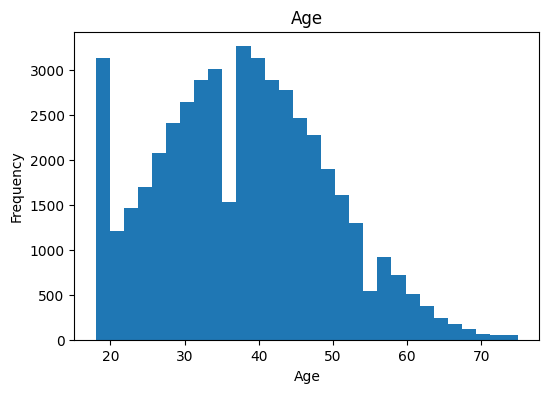

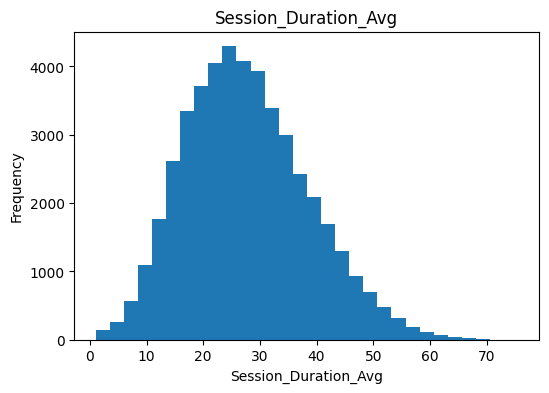

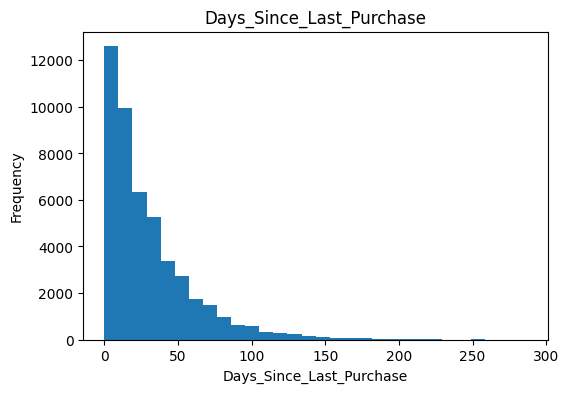

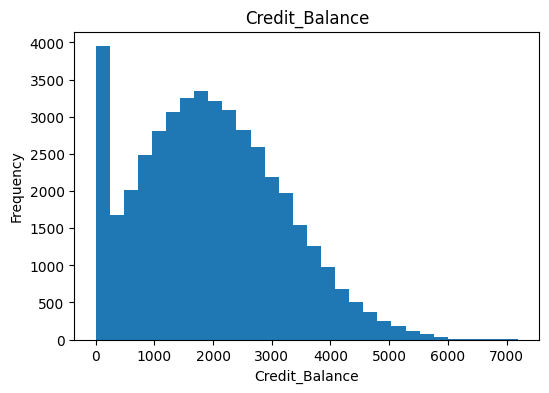

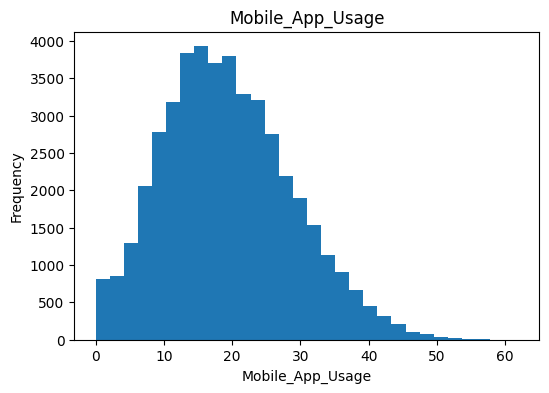

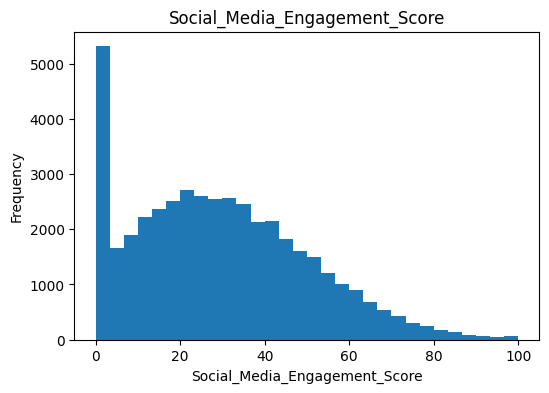

In [169]:
cols_to_plot = [
    "Age",
    "Session_Duration_Avg",
    "Days_Since_Last_Purchase",
    "Credit_Balance",
    "Mobile_App_Usage",
    "Social_Media_Engagement_Score"
]

for col in cols_to_plot:
    plt.figure(figsize=(6, 4))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [170]:
high_missing_cols = [
    "Social_Media_Engagement_Score",
    "Credit_Balance",
    "Mobile_App_Usage"
]

for col in high_missing_cols:
    df[col + "_Missing"] = df[col].isna().astype(int)

In [171]:
df[
    [
        "Social_Media_Engagement_Score_Missing",
        "Credit_Balance_Missing",
        "Mobile_App_Usage_Missing"
    ]
].sum()

,0
Social_Media_Engagement_Score_Missing,6000
Credit_Balance_Missing,5500
Mobile_App_Usage_Missing,5000


In [172]:
numeric_missing_cols = df.columns[df.isna().any()].tolist()

for col in numeric_missing_cols:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())

In [173]:
df.isna().sum().sort_values(ascending=False)

,0
Age,0
Gender,0
Country,0
City,0
Membership_Years,0
Login_Frequency,0
Session_Duration_Avg,0
Pages_Per_Session,0
Cart_Abandonment_Rate,0
Wishlist_Items,0


In [174]:
df.shape

(50000, 28)

In [175]:
print("Invalid Age:",
      ((df["Age"] < 18) | (df["Age"] > 100)).sum())

print("Negative Total Purchases:",
      (df["Total_Purchases"] < 0).sum())

print("Cart Abandonment > 100:",
      (df["Cart_Abandonment_Rate"] > 100).sum())

print("Discount Usage > 100:",
      (df["Discount_Usage_Rate"] > 100).sum())

Invalid Age: 0
Negative Total Purchases: 0
Cart Abandonment > 100: 0
Discount Usage > 100: 0


In [176]:
print("Rows:", len(df))
print("Churned:", (df["Churned"] == 1).sum())
print("Retained:", (df["Churned"] == 0).sum())
print("Churn Rate:", df["Churned"].mean() * 100)

Rows: 50000
Churned: 14450
Retained: 35550
Churn Rate: 28.9


##  Feature Engineering

In [177]:
age_bins = [17, 24, 34, 44, 54, 64, 100]

age_labels = [
    "18-24",
    "25-34",
    "35-44",
    "45-54",
    "55-64",
    "65+"
]

df["Age_Group"] = pd.cut(
    df["Age"],
    bins=age_bins,
    labels=age_labels
)

In [178]:
df["Age_Group"].value_counts().sort_index()

,count
Age_Group,
18-24,6637
25-34,12382
35-44,17690
45-54,9548
55-64,3187
65+,556


In [179]:
df["Age_Group"].isna().sum()

np.int64(0)

In [180]:
df["Customer_Value_Segment"] = pd.qcut(
    df["Lifetime_Value"],
    q=4,
    labels=[
        "Low Value",
        "Medium Value",
        "High Value",
        "VIP"
    ]
)

In [181]:
df["Customer_Value_Segment"].value_counts()

,count
Customer_Value_Segment,
Low Value,12500
Medium Value,12500
High Value,12500
VIP,12500


In [182]:
df["Recency_Segment"] = pd.qcut(
    df["Days_Since_Last_Purchase"],
    q=4,
    labels=[
        "Very Recent",
        "Recent",
        "Inactive",
        "Highly Inactive"
    ]
)

In [183]:
df["Recency_Segment"].value_counts()

,count
Recency_Segment,
Recent,14571
Very Recent,12594
Highly Inactive,12426
Inactive,10409


In [184]:
df.groupby(
    "Recency_Segment",
    observed=False
)["Days_Since_Last_Purchase"].agg(
    ["min", "median", "max"]
)

,min,median,max
Recency_Segment,,,
Very Recent,0.0,4.0,9.0
Recent,10.0,16.0,21.0
Inactive,22.0,29.0,39.0
Highly Inactive,40.0,60.0,287.0


In [185]:
engagement_cols = [
    "Login_Frequency",
    "Session_Duration_Avg",
    "Pages_Per_Session",
    "Mobile_App_Usage",
    "Email_Open_Rate",
    "Social_Media_Engagement_Score"
]

In [186]:
scaler = StandardScaler()

In [187]:
engagement_scaled = scaler.fit_transform(
    df[engagement_cols]
)

In [188]:
df["Engagement_Score"] = engagement_scaled.mean(axis=1)

In [189]:
engagement_scaled.shape

(50000, 6)

In [190]:
df["Engagement_Score"].describe()

,Engagement_Score
count,5.000000e+04
mean,-3.794298e-17
std,8.258058e-01
min,-1.768326e+00
25%,-6.285426e-01
50%,-1.226480e-01
75%,5.221782e-01
max,3.568293e+00


In [191]:
df["Engagement_Segment"] = pd.qcut(
    df["Engagement_Score"],
    q=4,
    labels=[
        "Very Low",
        "Low",
        "High",
        "Very High"
    ]
)

In [192]:
df["Engagement_Segment"].value_counts()

,count
Engagement_Segment,
Very Low,12500
Low,12500
High,12500
Very High,12500


In [193]:
new_features = [
    "Age_Group",
    "Customer_Value_Segment",
    "Recency_Segment",
    "Engagement_Score",
    "Engagement_Segment"
]

df[new_features].head(10)

,Age_Group,Customer_Value_Segment,Recency_Segment,Engagement_Score,Engagement_Segment
0,35-44,Medium Value,Inactive,-0.194713,Low
1,35-44,Medium Value,Highly Inactive,0.708075,Very High
2,45-54,High Value,Recent,-0.862482,Very Low
3,55-64,VIP,Highly Inactive,1.367811,Very High
4,35-44,VIP,Highly Inactive,1.983217,Very High
5,35-44,VIP,Inactive,-0.630864,Very Low
6,55-64,VIP,Recent,1.756112,Very High
7,45-54,High Value,Very Recent,-0.418272,Low
8,25-34,Low Value,Recent,-0.307211,Low
9,35-44,Medium Value,Inactive,-0.266933,Low


## Exploratory Business Analysis

A focused exploratory analysis is performed to answer the core customer retention questions using the cleaned and feature-engineered dataset.

The analysis focuses on customer profile, value, recency and engagement rather than exhaustively exploring every variable.

In [194]:
overall_churn = df["Churned"].mean() * 100

print(f"Overall Churn Rate: {overall_churn:.1f}%")

Overall Churn Rate: 28.9%


In [195]:
churn_by_value = (
    df.groupby(
        "Customer_Value_Segment",
        observed=False
    )
    .agg(
        Customers=("Churned", "size"),
        Churned_Customers=("Churned", "sum"),
        Churn_Rate=("Churned", "mean")
    )
)

churn_by_value["Churn_Rate"] *= 100

churn_by_value

,Customers,Churned_Customers,Churn_Rate
Customer_Value_Segment,,,
Low Value,12500,5162,41.296
Medium Value,12500,2532,20.256
High Value,12500,1800,14.400
VIP,12500,4956,39.648


In [196]:
churn_by_recency = (
    df.groupby(
        "Recency_Segment",
        observed=False
    )
    .agg(
        Customers=("Churned", "size"),
        Churn_Rate=("Churned", "mean")
    )
)

churn_by_recency["Churn_Rate"] *= 100

churn_by_recency

,Customers,Churn_Rate
Recency_Segment,,
Very Recent,12594,22.423376
Recent,14571,26.717452
Inactive,10409,28.936497
Highly Inactive,12426,37.992918


In [197]:
churn_by_engagement = (
    df.groupby(
        "Engagement_Segment",
        observed=False
    )
    .agg(
        Customers=("Churned", "size"),
        Churn_Rate=("Churned", "mean")
    )
)

churn_by_engagement["Churn_Rate"] *= 100

churn_by_engagement

,Customers,Churn_Rate
Engagement_Segment,,
Very Low,12500,52.848
Low,12500,23.208
High,12500,20.616
Very High,12500,18.928


### High-Value Customers with Low Engagement

This analysis examines whether commercially valuable customers with relatively low engagement represent a potential retention priority.

High Value and VIP customers are combined with the Very Low and Low engagement segments to identify this customer group.

In [198]:
priority_customers = df[
    (df["Customer_Value_Segment"].isin(["High Value", "VIP"])) &
    (df["Engagement_Segment"].isin(["Very Low", "Low"]))
]

print("Priority Customers:", len(priority_customers))

print(
    "Priority Customer Churn Rate:",
    priority_customers["Churned"].mean() * 100
)

print(
    "Overall Churn Rate:",
    df["Churned"].mean() * 100
)

Priority Customers: 6701
Priority Customer Churn Rate: 36.44232204148635
Overall Churn Rate: 28.9


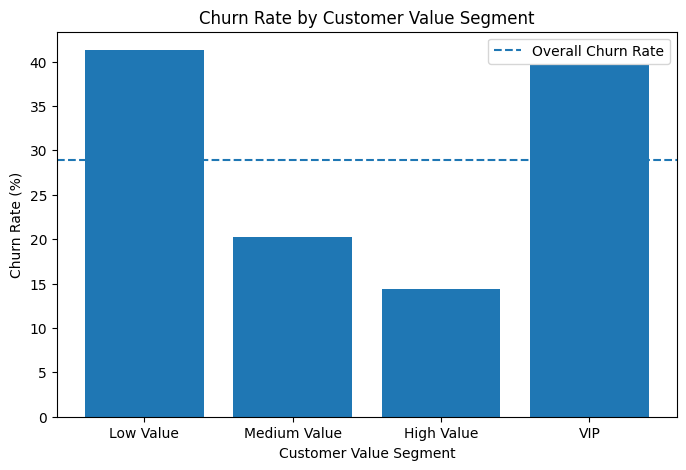

In [199]:
plt.figure(figsize=(8, 5))

plt.bar(
    churn_by_value.index.astype(str),
    churn_by_value["Churn_Rate"]
)

plt.axhline(
    overall_churn,
    linestyle="--",
    label="Overall Churn Rate"
)

plt.title("Churn Rate by Customer Value Segment")
plt.xlabel("Customer Value Segment")
plt.ylabel("Churn Rate (%)")
plt.legend()

plt.show()

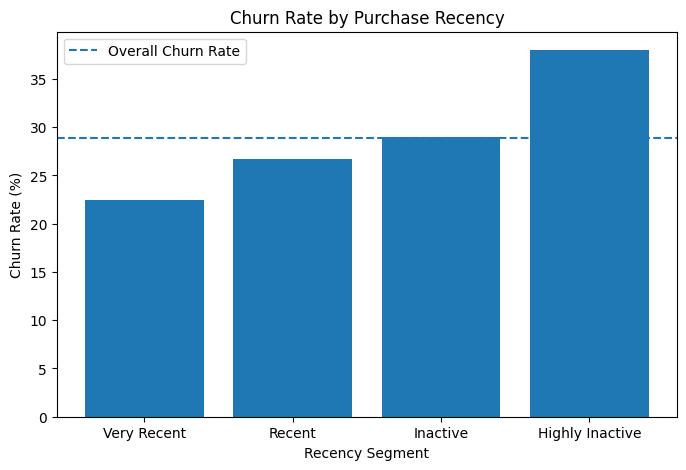

In [200]:
plt.figure(figsize=(8, 5))

plt.bar(
    churn_by_recency.index.astype(str),
    churn_by_recency["Churn_Rate"]
)

plt.axhline(
    overall_churn,
    linestyle="--",
    label="Overall Churn Rate"
)

plt.title("Churn Rate by Purchase Recency")
plt.xlabel("Recency Segment")
plt.ylabel("Churn Rate (%)")
plt.legend()

plt.show()

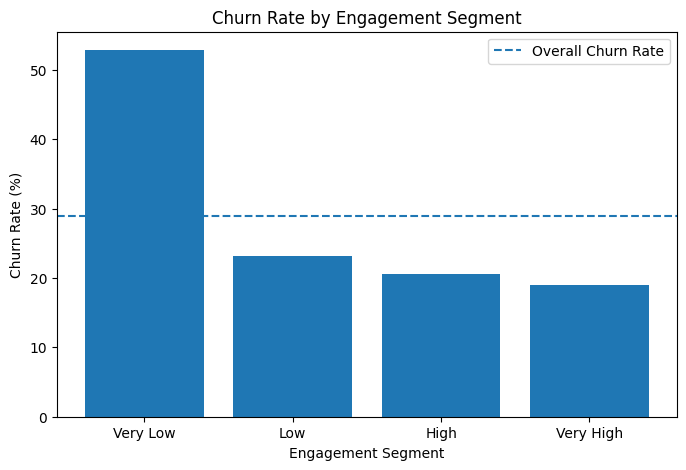

In [201]:
plt.figure(figsize=(8, 5))

plt.bar(
    churn_by_engagement.index.astype(str),
    churn_by_engagement["Churn_Rate"]
)

plt.axhline(
    overall_churn,
    linestyle="--",
    label="Overall Churn Rate"
)

plt.title("Churn Rate by Engagement Segment")
plt.xlabel("Engagement Segment")
plt.ylabel("Churn Rate (%)")
plt.legend()

plt.show()

##  Key Findings

### 1. Overall Churn

The overall customer churn rate is 28.9%, with 14,450 of 50,000 customers classified as churned.

### 2. Customer Engagement Shows a Strong Relationship with Churn

Customers in the Very Low Engagement segment recorded the highest churn rate at 52.8%, compared with an overall churn rate of 28.9%.

Churn decreased progressively across the higher engagement segments:

- Very Low: 52.8%
- Low: 23.2%
- High: 20.6%
- Very High: 18.9%

This indicates a strong association between lower customer engagement and higher churn.

### 3. Purchase Inactivity is Associated with Higher Churn

Churn increased progressively as the time since a customer's last purchase increased.

- Very Recent: 22.4%
- Recent: 26.7%
- Inactive: 28.9%
- Highly Inactive: 38.0%

Customers who had not purchased for 40 days or more therefore showed substantially higher churn than recently active customers.

### 4. Customer Value Does Not Have a Simple Relationship with Churn

The High Value segment recorded the lowest churn rate at 14.4%, while the VIP segment recorded a much higher churn rate of 39.6%.

This suggests that high customer value alone does not guarantee customer retention and that VIP customers may require additional investigation.
### 5. High-Value Customers with Low Engagement Represent a Retention Priority

A total of 6,701 customers were classified as High Value or VIP while also having Low or Very Low engagement.

This group recorded a churn rate of 36.4%, compared with the overall churn rate of 28.9%.

This suggests that combining customer value with behavioural engagement provides a more useful retention lens than customer value alone.

In [202]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Missing Values:", df.isna().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())
print("Churned Customers:", df["Churned"].sum())
print("Churn Rate:", df["Churned"].mean() * 100)

Rows: 50000
Columns: 33
Missing Values: 0
Duplicate Rows: 0
Churned Customers: 14450
Churn Rate: 28.9


## Business Recommendations

### 1. Prioritise Very Low Engagement Customers

Customers in the Very Low Engagement segment recorded a churn rate of 52.8%, substantially above the overall rate of 28.9%.

Retention initiatives should prioritise customers showing consistently low levels of digital engagement.

### 2. Use Purchase Inactivity as an Early Warning Signal

Churn rises progressively as the time since the last purchase increases, reaching 38.0% among Highly Inactive customers.

Re-engagement activity should therefore target customers before prolonged inactivity develops.

### 3. Investigate Elevated VIP Churn

VIP customers recorded a churn rate of 39.6%, despite belonging to the highest Lifetime Value quartile.

Further analysis should investigate the behavioural and service factors associated with churn within this commercially important group.

### 4. Combine Customer Value and Engagement

High-value customers with Low or Very Low engagement recorded a churn rate of 36.4%, above the overall rate of 28.9%.

Retention prioritisation should therefore combine customer value with behavioural engagement rather than relying on customer value alone.

## Limitations

- The analysis identifies associations with churn and should not be interpreted as evidence of causation.
- Median imputation was used for missing numeric values and may reduce some natural variation in the affected variables.
- The Engagement Score is a project-specific composite measure created by equally weighting six standardised engagement variables and is not an externally validated business metric.
- Customer value, recency and engagement segments were analytically defined rather than supplied as official business classifications.
- The dataset does not provide a complete transaction-level timeline, limiting longitudinal and cohort analysis.

## Final Dataset Export

The final cleaned and feature-engineered customer dataset is exported for potential future SQL, dashboarding and predictive modelling work.

In [203]:
df.to_csv(
    "customer_retention_analytics_final.csv",
    index=False
)

In [204]:
final_df = pd.read_csv(
    "customer_retention_analytics_final.csv"
)

print(final_df.shape)
print(final_df.isna().sum().sum())

(50000, 33)
0
